In [ ]:
from fairnessinsight.Datasets.HeartDataset import HeartDataset
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [3]:
h = HeartDataset()
h.num_repetitions = 1
h.execute_models()

({'LogisticRegression': 80.328,
  'DecisionTreeClassifier': 72.131,
  'RandomForestClassifier': 81.967},
 {'LogisticRegression': 82.353,
  'DecisionTreeClassifier': 71.186,
  'RandomForestClassifier': 83.077})

# Permutation Importance (SKLEARN Method)

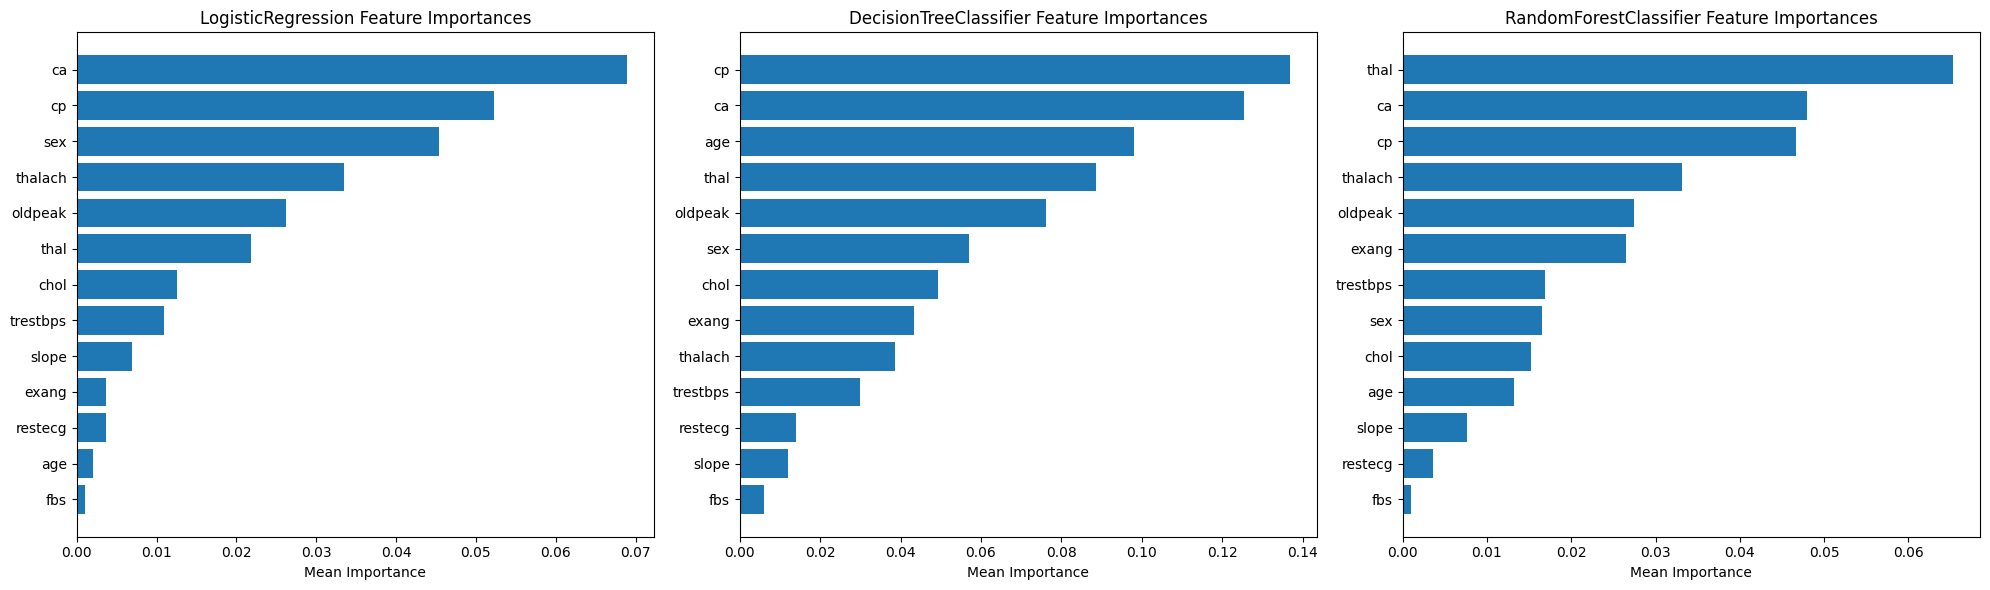

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=len(h.models), figsize=(20, 6))

for ax, (model_name, clf) in zip(axes, h.models.items()):
    X = h.dataset[h.X_test.columns]
    y = h.dataset[h.predicted_attr]
    result = permutation_importance(clf, X, y, n_repeats=10, random_state=0)

    feature_names = X.columns
    importance_means = result.importances_mean

    # Sort the importances and feature names
    sorted_idx = importance_means.argsort()
    sorted_importance_means = importance_means[sorted_idx]
    sorted_feature_names = feature_names[sorted_idx]

    ax.barh(sorted_feature_names, sorted_importance_means, align='center')
    ax.set_xlabel('Mean Importance')
    ax.set_title(f'{model_name} Feature Importances')

plt.tight_layout()
plt.show()

# Correlation (from pandas, pearson's correlation)

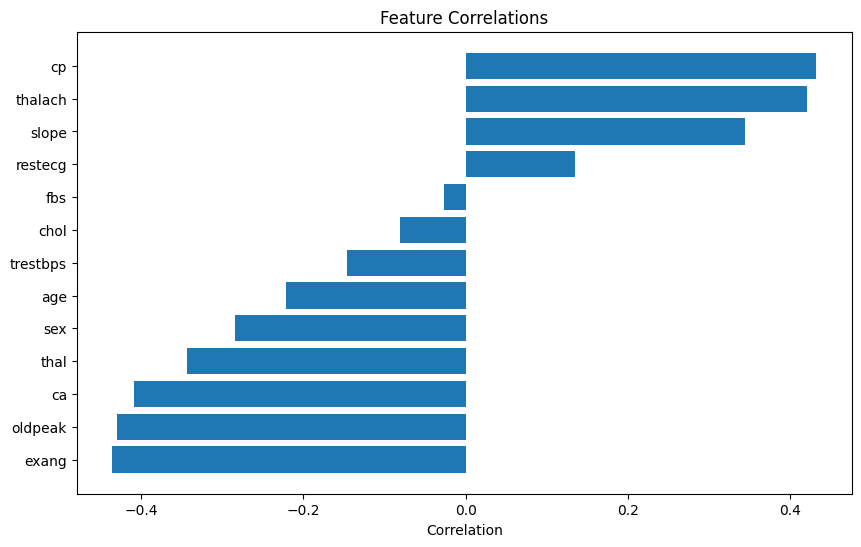

In [33]:
correlations = h.dataset.corr()['target'].drop('target').sort_values()
# plot correlations
plt.figure(figsize=(10, 6))
plt.barh(correlations.index, correlations, align='center')
plt.xlabel('Correlation')
plt.title('Feature Correlations')
plt.show()
